# Taller 03: Problemas de Satisfacción de Restricciones 
### Inteligencia Artificial ELP 8012 - Universidad del Norte - Profesor: Eduardo Zurek, PH.D. 
### **Grupo:** Natalia Carpintero, Paula Núñez e Isabella Arrieta.

**Problema:** dado un grafo no dirigido representado por una matriz de adyacencias
simétrica $N \times N$ ($N < 21$, con $1$ = arista existente y $0$ = arista inexistente),
encontrar una asignación de colores a los nodos tal que **dos nodos adyacentes nunca
tengan el mismo color**, usando el **menor número de colores posible**.


## Acerca de CSP

Este problema se modela como un **Problema de Satisfacción de Restricciones (CSP)**:

- **Variables:** los nodos del grafo ($v_0, v_1, \dots, v_{n-1}$).
- **Dominios:** el conjunto de colores disponibles $\{0, 1, \dots, k-1\}$ para cada nodo.
- **Restricciones:** para toda arista $(u, v)$, se debe cumplir $color(u) \neq color(v)$.

Para resolverlo se implementa el algoritmo **BT-FC-DO**:

| Sigla | Significa | Qué hace |
|---|---|---|
| **BT** | *Backtracking* | Búsqueda en profundidad que asigna un color a un nodo y retrocede (backtrack) si una elección lleva a un callejón sin salida. |
| **FC** | *Forward Checking* | Cada vez que se asigna un color a un nodo, se elimina ese color de los dominios de sus vecinos aún no asignados. Si el dominio de algún vecino queda vacío, se detecta el fallo **antes** de seguir bajando en el árbol de búsqueda (poda temprana). |
| **DO** | *Dynamic Ordering* | En cada paso se elige el **siguiente nodo a colorear dinámicamente**, usando la heurística MRV (*Minimum Remaining Values*: el nodo con menos colores disponibles en su dominio) y, como criterio de desempate, el nodo de **mayor grado** (más conexiones), ya que suele ser el más restrictivo. |

Estructura del cuaderno:
1. Utilidades y validación.
2. Carga del grafo (desde archivo `.txt` o generado aleatoriamente).
3. Algoritmo BT-FC-DO.
4. Visualización del grafo coloreado.
5. Celda de ejecución donde se elige el origen del grafo y se corre todo el proceso.


## Implementación

In [41]:
# ---------------------------
# Carga de Librerias
# ---------------------------
import re
import math
import colorsys
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Validación
# ---------------------------
def validar_tamano(n):
    '''Valida que el número de nodos N cumpla 1 <= N < 21.'''
    if not (1 <= n < 21):
        raise ValueError(f"N debe ser menor que 21 (recibido: {n})")
    
# ---------------------------
# Carga de la matriz
# ---------------------------
def leer_matriz_desde_archivo(ruta):
    '''Lee una matriz de adyacencias simétrica desde un archivo de texto plano.'''
    with open(ruta, 'r', encoding='utf-8') as archivo:
        lineas = []
        for linea in archivo:
            linea = linea.strip()
            if not linea or linea.startswith('#'):
                continue
            fila = [int(x) for x in re.split(r'[\s,;]+', linea) if x]
            lineas.append(fila)
    if not lineas:
        raise ValueError('El archivo no contiene una matriz de adyacencias válida.')

    matriz = np.array(lineas, dtype=int)

    if matriz.shape[0] != matriz.shape[1]:
        raise ValueError('La matriz debe ser cuadrada.')

    validar_tamano(matriz.shape[0])

    if not np.all((matriz == 0) | (matriz == 1)):
        raise ValueError('La matriz solo puede contener 0 o 1.')
    if not np.allclose(matriz, matriz.T):
        raise ValueError('La matriz debe ser simétrica.')

    return matriz

# ---------------------------
# Generación aleatoria
# ---------------------------
def generar_grafo_aleatorio(n, probabilidad=0.35, semilla=42):
    '''Genera una matriz de adyacencias simétrica aleatoria de tamaño n x n.'''
    validar_tamano(n)
    rng = np.random.default_rng(semilla)
    matriz = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < probabilidad:
                matriz[i, j] = 1
                matriz[j, i] = 1
    return matriz

# ---------------------------
# Algoritmo BT-FC-DO
# ---------------------------
def bt_fc_do_coloreo(matriz, num_colores=None):
    '''Resuelve el coloreo de grafos como CSP con Backtracking + Forward Checking
    + Ordenamiento Dinámico (BT-FC-DO).

    Si num_colores es None, busca automáticamente el número cromático mínimo.
    Retorna (asignacion, num_colores) en ese caso, o solo la asignación (dict)
    si num_colores fue especificado.
    '''
    n = matriz.shape[0]
    if num_colores is None:
        for k in range(1, n + 1):
            solucion = bt_fc_do_coloreo(matriz, k)
            if solucion is not None:
                return solucion, k
        return None, None

    dominios = {v: list(range(num_colores)) for v in range(n)}

    def propagar(asignacion, dominios_actuales, vertice_nuevo, color_nuevo):
        dominios_nuevos = {k: list(v) for k, v in dominios_actuales.items()}
        for u in range(n):
            if u in asignacion or u == vertice_nuevo:
                continue
            if matriz[vertice_nuevo, u] == 1 and color_nuevo in dominios_nuevos[u]:
                dominios_nuevos[u].remove(color_nuevo)
                if not dominios_nuevos[u]:
                    return None
        return dominios_nuevos

    def resolver(asignacion, dominios_actuales):
        if len(asignacion) == n:
            return asignacion.copy()

        no_asignados = [v for v in range(n) if v not in asignacion]
        v = min(no_asignados, key=lambda x: (len(dominios_actuales[x]), -matriz[x].sum()))

        for color in dominios_actuales[v]:
            nueva_asignacion = asignacion.copy()
            nueva_asignacion[v] = color

            dominios_propagados = propagar(asignacion, dominios_actuales, v, color)
            if dominios_propagados is not None:
                dominios_propagados[v] = [color]
                resultado = resolver(nueva_asignacion, dominios_propagados)
                if resultado is not None:
                    return resultado

        return None

    return resolver({}, dominios)

# ---------------------------
# Visualización
# ---------------------------
def generar_paleta(num_colores):
    """Genera una lista de num_colores colores distintos en formato hexadecimal."""
    if num_colores <= 10:
        base = ['#e74c3c', '#2ecc71', '#3498db', '#f1c40f', '#9b59b6',
                '#1abc9c', '#e67e22', '#95a5a6', '#34495e', '#f39c12']
        return base[:num_colores]
    return [
        '#%02x%02x%02x' % tuple(int(c * 255) for c in colorsys.hsv_to_rgb(i / num_colores, 0.65, 0.9))
        for i in range(num_colores)
    ]


def dibujar_grafo(matriz, asignacion, guardar_png=True, ruta_salida='coloreo.png'):
    """Dibuja el grafo con sus nodos coloreados, mostrándolo en el cuaderno.

    El tamaño de los nodos, la fuente y la figura se ajustan automáticamente
    según el número de nodos (n), para que el resultado se vea bien tanto con
    grafos pequeños (pocos nodos grandes) como con grafos grandes (muchos
    nodos pequeños).
    """
    n = matriz.shape[0]

    pos = {}
    for i in range(n):
        angulo = 2 * math.pi * i / n
        pos[i] = (math.cos(angulo), math.sin(angulo))

    num_colores = max(asignacion.values()) + 1
    colores = generar_paleta(num_colores)

    # Escalado dinámico: con pocos nodos, cada uno ocupa más espacio en el
    # círculo, así que hay que reducir su tamaño en pantalla para que no se
    # vean gigantes ni se salgan del margen; con muchos nodos, hay que
    # achicarlos para que no se amontonen.
    tam_nodo = float(np.clip(5500 / n, 350, 1400))
    tam_fuente = float(np.clip(15 - 0.15 * n, 9, 13))
    lado_figura = float(np.clip(4.5 + 0.22 * n, 6, 10))

    fig, ax = plt.subplots(figsize=(lado_figura, lado_figura))

    for i in range(n):
        for j in range(i + 1, n):
            if matriz[i, j] == 1:
                x1, y1 = pos[i]
                x2, y2 = pos[j]
                ax.plot([x1, x2], [y1, y2], color='#999999', alpha=0.7, linewidth=1.2, zorder=1)

    for i in range(n):
        x, y = pos[i]
        color = colores[asignacion[i]]
        ax.scatter(x, y, s=tam_nodo, color=color, edgecolors='black', linewidths=1.1, zorder=2)
        ax.text(x, y, str(i + 1), ha='center', va='center', fontsize=tam_fuente, 
        fontweight='bold', zorder=3, color='black')
        
    ax.set_title(f'Coloración de grafo - BT-FC-DO (k={num_colores} colores)', fontsize=13, pad=14)
    ax.set_aspect('equal')
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.axis('off')

    handles = [ 
    plt.Line2D([0], [0], marker='o', linestyle='', markersize=10, 
            markerfacecolor=colores[c], markeredgecolor='black', label=f'Color {c + 1}') 
    for c in range(num_colores) 
    ]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
            ncol=min(num_colores, 6), frameon=False, fontsize=10)

    fig.tight_layout()

    if guardar_png:
        plt.savefig(ruta_salida, dpi=150, bbox_inches='tight')

    plt.show()   # <- muestra la figura directamente en el cuaderno

## Ejecución principal

Configure las siguientes variables y ejecute la celda:

- `ORIGEN`:
  - `"archivo"` — carga el grafo desde un `.txt` (defina `RUTA_ARCHIVO`).
  - `"aleatorio"` — genera un grafo aleatorio (defina `N`, `PROBABILIDAD` y `SEMILLA`).
- `N`, `PROBABILIDAD`, `SEMILLA`: solo se usan si `ORIGEN = "aleatorio"`.
- `RUTA_ARCHIVO`: solo se usa si `ORIGEN = "archivo"`.

La celda calcula automáticamente el número cromático mínimo (probando
$k = 1, 2, 3, \dots$) y muestra el grafo coloreado al final.

Matriz cargada desde archivo: grafo.txt (N=5)
Matriz de adyacencias:
[[0 1 0 1 1]
 [1 0 1 0 1]
 [0 1 0 1 1]
 [1 0 1 0 1]
 [1 1 1 1 0]]
Número mínimo de colores usados (número cromático): 3
Asignación por nodo: {5: 1, 1: 2, 2: 3, 3: 2, 4: 3}


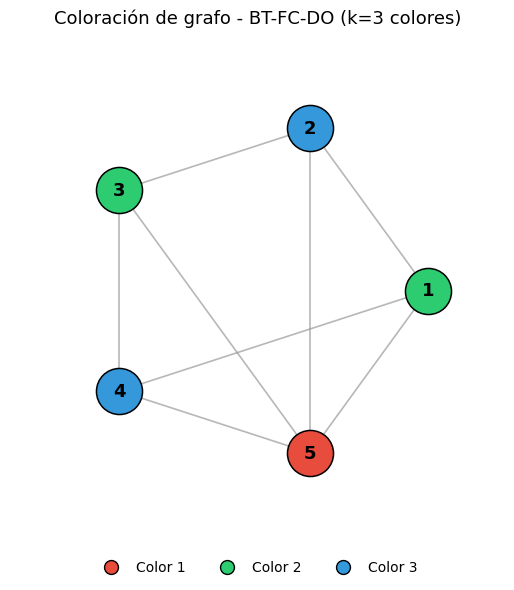

In [50]:
# --------- Parámetros configurables ---------
ORIGEN = "archivo"      # "archivo" o "aleatorio"

# Usados si ORIGEN == "archivo"
RUTA_ARCHIVO = "grafo.txt"

# Usados si ORIGEN == "aleatorio"
N = 10
PROBABILIDAD = 0.35
SEMILLA = 7                # usar None para que cambie en cada ejecución
# ---------------------------------------------

if ORIGEN == "archivo":
    matriz = leer_matriz_desde_archivo(RUTA_ARCHIVO)
    print(f"Matriz cargada desde archivo: {RUTA_ARCHIVO} (N={matriz.shape[0]})")
elif ORIGEN == "aleatorio":
    matriz = generar_grafo_aleatorio(N, probabilidad=PROBABILIDAD, semilla=SEMILLA)
    print(f"Grafo aleatorio generado (N={N}, probabilidad={PROBABILIDAD}, semilla={SEMILLA})")
else:
    raise ValueError('ORIGEN debe ser "archivo" o "aleatorio"')

print("Matriz de adyacencias:")
print(matriz)

solucion, num_colores = bt_fc_do_coloreo(matriz)
asignacion_mostrada = {nodo + 1: color + 1 for nodo, color in solucion.items()}

if solucion is None:
    print("No existe una coloración válida para este grafo.")
else:
    print(f"Número mínimo de colores usados (número cromático): {num_colores}")
    print("Asignación por nodo:", asignacion_mostrada)
    dibujar_grafo(matriz, solucion, guardar_png=True)
